# 第 15 章 OpenCV 特徵偵測與匹配

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 15-2-4 程式範例：ORB 關鍵點偵測

正臉影像檢測到的關鍵點數量：500
正臉影像描述子形狀：(500, 32)
側臉影像檢測到的關鍵點數量：500
側臉影像描述子形狀：(500, 32)


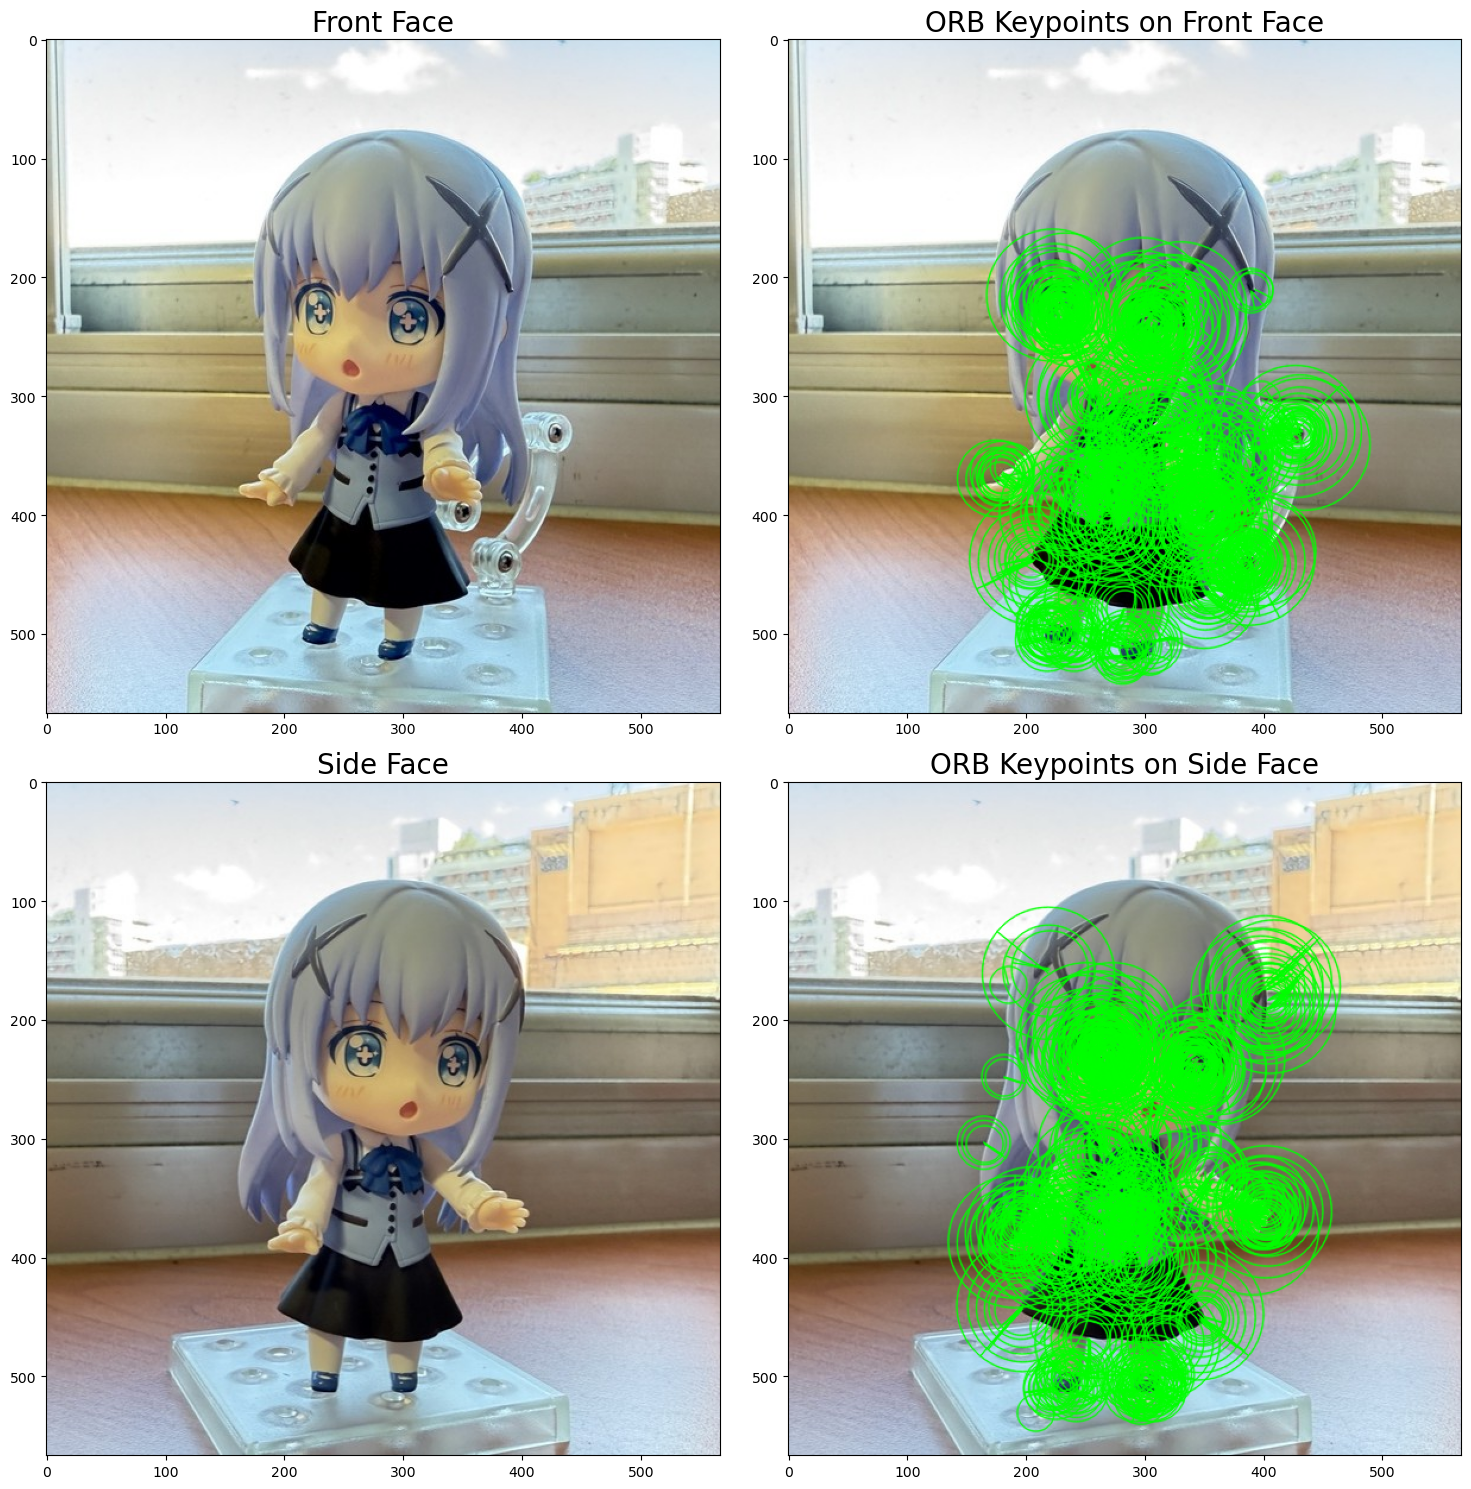

In [2]:
# 讀取正臉與側臉影像並轉為灰階
front_face = cv2.imread('sample/front_face.jpg')
side_face = cv2.imread('sample/side_face.jpg')
gray_front = cv2.cvtColor(front_face, cv2.COLOR_BGR2GRAY)
gray_side = cv2.cvtColor(side_face, cv2.COLOR_BGR2GRAY)

# 初始化 ORB 偵測器
orb = cv2.ORB_create()

# 偵測關鍵點與計算描述子
keypoints_front, descriptors_front = orb.detectAndCompute(gray_front, None)
keypoints_side, descriptors_side = orb.detectAndCompute(gray_side, None)

# 顯示關鍵點數量與描述子形狀
print(f"正臉影像偵測到的關鍵點數量：{len(keypoints_front)}")
print(f"正臉影像描述子形狀：{descriptors_front.shape}")
print(f"側臉影像偵測到的關鍵點數量：{len(keypoints_side)}")
print(f"側臉影像描述子形狀：{descriptors_side.shape}")

# 繪製關鍵點到原始影像上
front_with_keypoints = cv2.drawKeypoints(front_face, keypoints_front, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
side_with_keypoints = cv2.drawKeypoints(side_face, keypoints_side, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 顯示結果
opencv_tools.show_img_by_matplotlib_2x2(
   'Front Face', front_face,
   'ORB Keypoints on Front Face', front_with_keypoints,
   'Side Face', side_face,
   'ORB Keypoints on Side Face', side_with_keypoints,
)

正臉影像檢測到的關鍵點數量：50
正臉影像描述子形狀：(50, 32)
側臉影像檢測到的關鍵點數量：50
側臉影像描述子形狀：(50, 32)


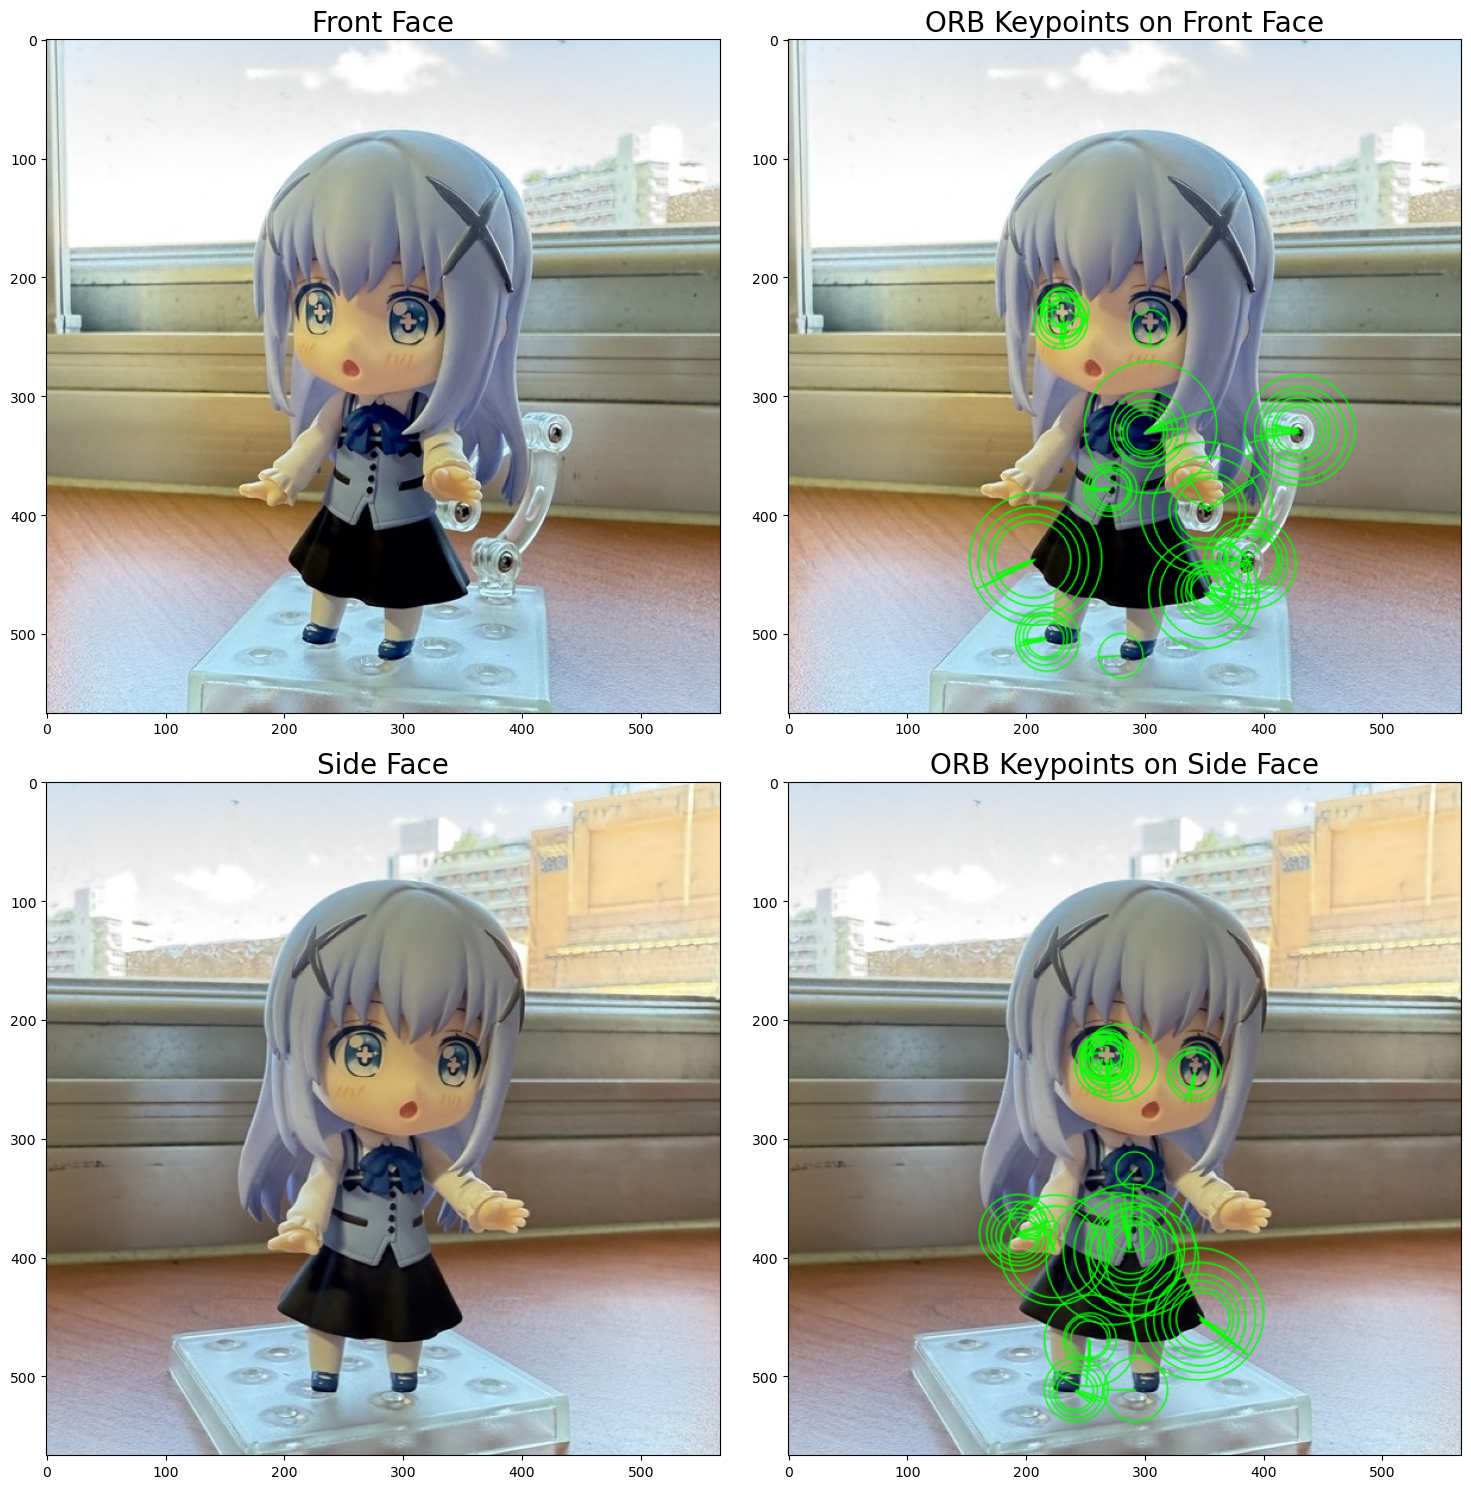

In [3]:
# 初始化 ORB 偵測器 (只找最強的 50 個關鍵點)
orb_50 = cv2.ORB_create(nfeatures=50)

# 偵測關鍵點與計算描述子
keypoints_50_front, descriptors_50_front = orb_50.detectAndCompute(gray_front, None)
keypoints_50_side, descriptors_50_side = orb_50.detectAndCompute(gray_side, None)

# 顯示關鍵點數量與描述子形狀
print(f"正臉影像偵測到的關鍵點數量：{len(keypoints_50_front)}")
print(f"正臉影像描述子形狀：{descriptors_50_front.shape}")
print(f"側臉影像偵測到的關鍵點數量：{len(descriptors_50_side)}")
print(f"側臉影像描述子形狀：{descriptors_50_side.shape}")

# 繪製關鍵點到影像上
front_with_50_keypoints = cv2.drawKeypoints(front_face, keypoints_50_front, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
side_with_50_keypoints = cv2.drawKeypoints(side_face, keypoints_50_side, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 顯示結果
opencv_tools.show_img_by_matplotlib_2x2(
   'Front Face', front_face,
   'ORB Keypoints on Front Face', front_with_50_keypoints,
   'Side Face', side_face,
   'ORB Keypoints on Side Face', side_with_50_keypoints,
)

### 15-3-3 程式範例：ORB 暴力匹配與結果視覺化

In [4]:
# 讀取正臉與側臉影像並轉為灰階
front_face = cv2.imread('sample/front_face.jpg')
side_face = cv2.imread('sample/side_face.jpg')
gray_front = cv2.cvtColor(front_face, cv2.COLOR_BGR2GRAY)
gray_side = cv2.cvtColor(side_face, cv2.COLOR_BGR2GRAY)

# 初始化 ORB 偵測器 (我們把關鍵點提升到前 1000 個)
orb = cv2.ORB_create(nfeatures=1000)

# 偵測關鍵點與計算描述子
keypoints_front, descriptors_front = orb.detectAndCompute(gray_front, None)
keypoints_side, descriptors_side = orb.detectAndCompute(gray_side, None)

# 建立暴力匹配器（針對 ORB 使用漢明距離）
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# 進行描述子匹配
matches = bf.match(descriptors_front, descriptors_side)

# 按匹配距離排序（距離越小越相似）
matches = sorted(matches, key=lambda x: x.distance)

# 輸出匹配對數量
print(f"找到的匹配對數量：{len(matches)}")

# 顯示前 10 個匹配對的距離
print("前 10 個匹配對的距離：")
for i, m in enumerate(matches[:10]):
    print(f"匹配對 {i+1}: 距離 = {m.distance}")

找到的匹配對數量：353
前 10 個匹配對的距離：
匹配對 1: 距離 = 11.0
匹配對 2: 距離 = 17.0
匹配對 3: 距離 = 18.0
匹配對 4: 距離 = 20.0
匹配對 5: 距離 = 20.0
匹配對 6: 距離 = 21.0
匹配對 7: 距離 = 22.0
匹配對 8: 距離 = 22.0
匹配對 9: 距離 = 22.0
匹配對 10: 距離 = 23.0


ORB Matching Results between Front and Side Face


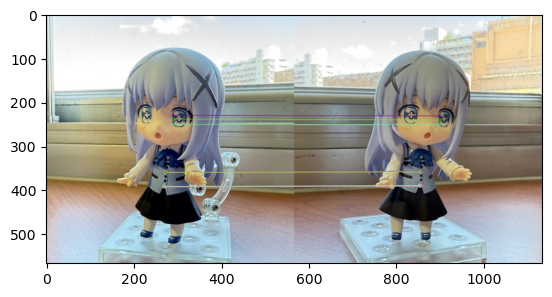

按下 Q 鍵，視窗即將關閉！


In [5]:
# 只繪製前 10 個最佳匹配對（避免影像太亂）
matches_to_draw = matches[:10]

# 繪製匹配結果
matched_img = cv2.drawMatches(
    front_face, keypoints_front, 
    side_face, keypoints_side, 
    matches_to_draw,
    None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# 顯示結果
print('ORB Matching Results between Front and Side Face')
opencv_tools.show_img_by_matplotlib(matched_img)
opencv_tools.show_img_by_opencv(matched_img)

ORB Matching Results between Front and Side Face


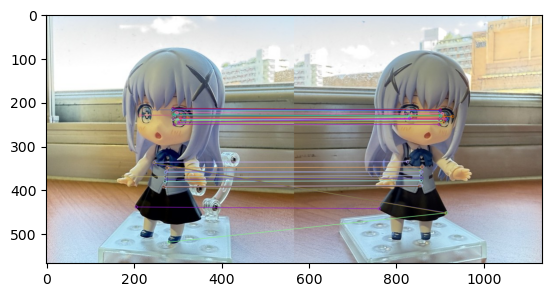

按下 Q 鍵，視窗即將關閉！


In [6]:
# 再繪製前 50 個最佳匹配對（觀察誤匹配如何出現）
matches_to_draw = matches[:50]

# 繪製匹配結果
matched_img = cv2.drawMatches(
    front_face, keypoints_front, 
    side_face, keypoints_side, 
    matches_to_draw,
    None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# 顯示結果
print('ORB Matching Results between Front and Side Face')
opencv_tools.show_img_by_matplotlib(matched_img)
opencv_tools.show_img_by_opencv(matched_img)

### 15-4-4 程式範例：顯示 SIFT 關鍵點並計算描述子

正臉影像檢測到的關鍵點數量：200
正臉影像描述子形狀：(200, 128)
側臉影像檢測到的關鍵點數量：200
側臉影像描述子形狀：(200, 128)


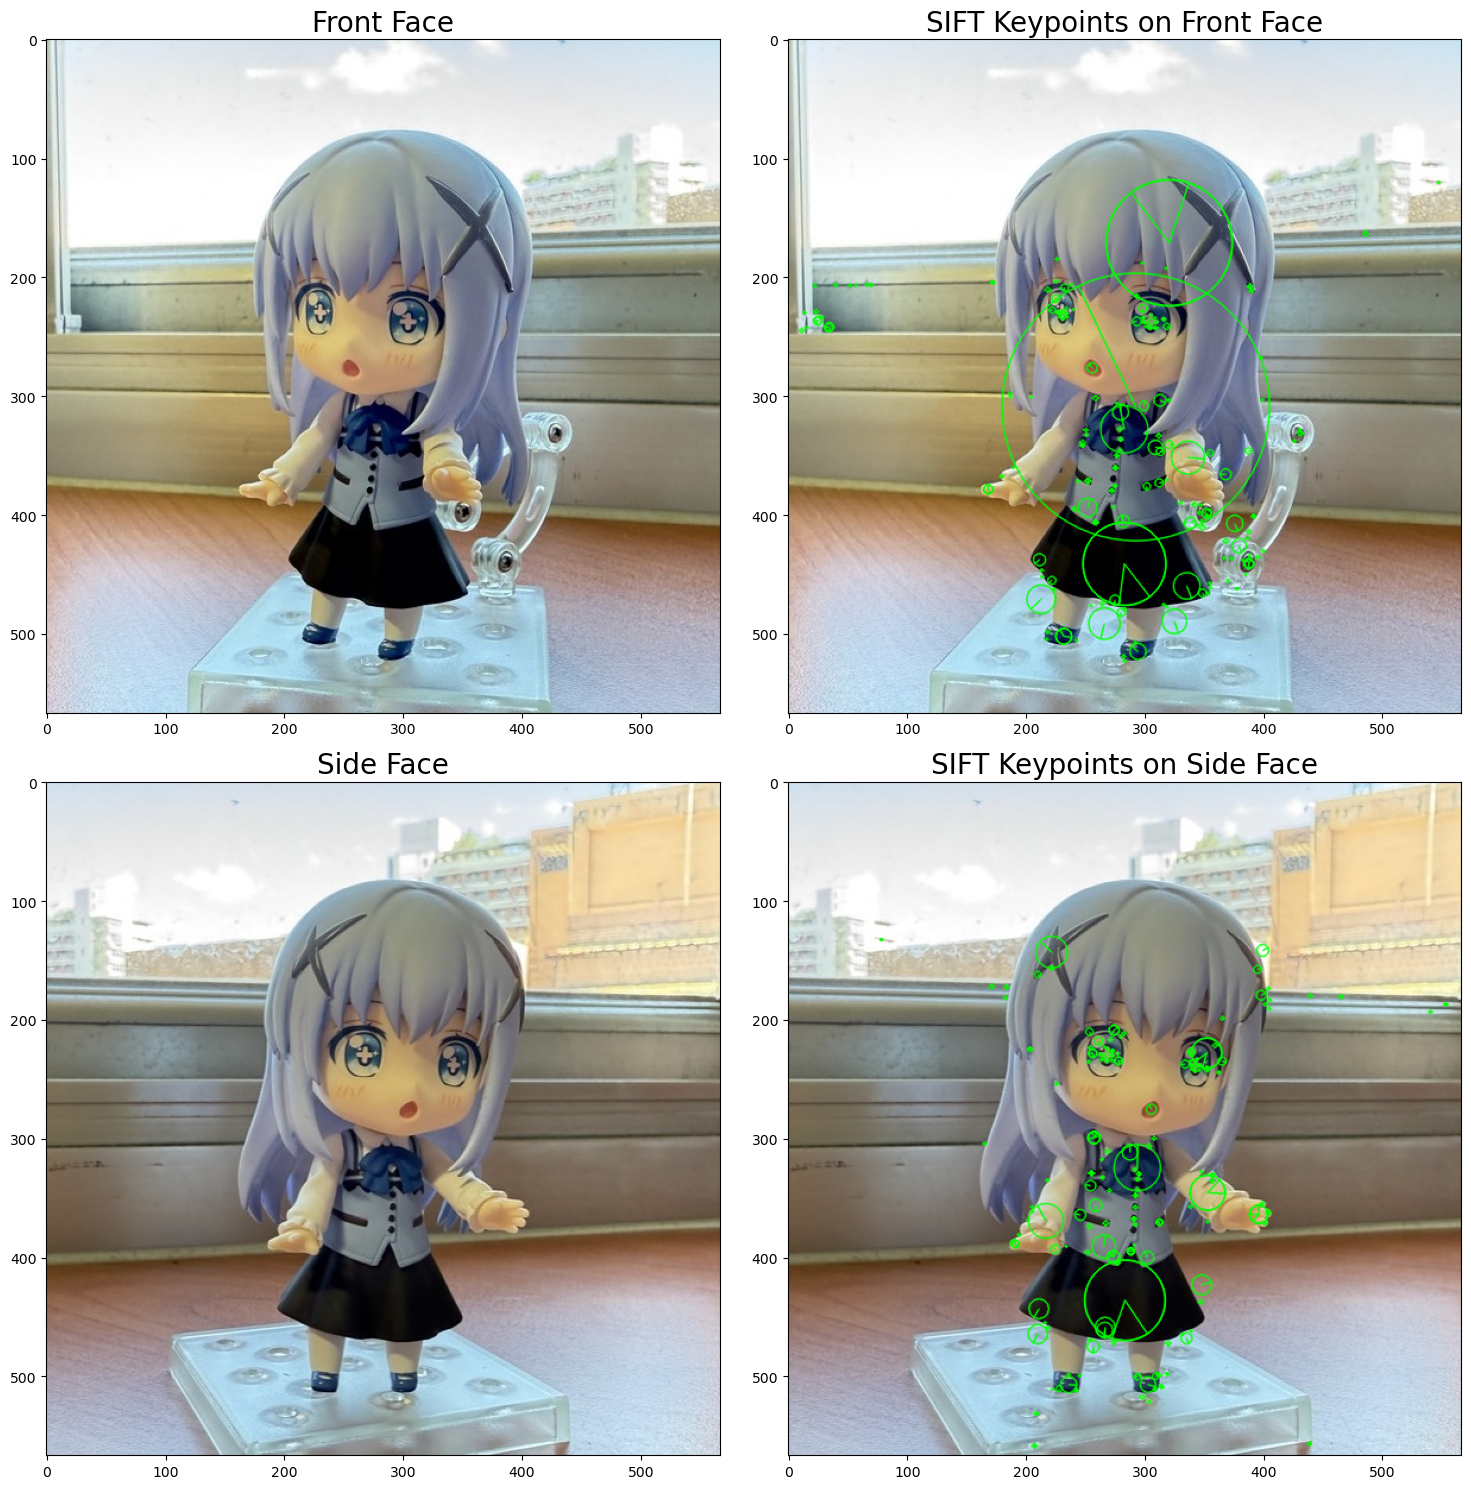

In [7]:
# 讀取正臉與側臉影像並轉為灰階
front_face = cv2.imread('sample/front_face.jpg')
side_face = cv2.imread('sample/side_face.jpg')
gray_front = cv2.cvtColor(front_face, cv2.COLOR_BGR2GRAY)
gray_side = cv2.cvtColor(side_face, cv2.COLOR_BGR2GRAY)

# 初始化 SIFT 偵測器（限制最多偵測 200 個關鍵點，避免畫面過於雜亂）
sift = cv2.SIFT_create(nfeatures=200)

# 偵測關鍵點與計算描述子
keypoints_front, descriptors_front = sift.detectAndCompute(gray_front, None)
keypoints_side, descriptors_side = sift.detectAndCompute(gray_side, None)

# 顯示關鍵點數量與描述子形狀
print(f"正臉影像偵測到的關鍵點數量：{len(keypoints_front)}")
print(f"正臉影像描述子形狀：{descriptors_front.shape}")
print(f"側臉影像偵測到的關鍵點數量：{len(keypoints_side)}")
print(f"側臉影像描述子形狀：{descriptors_side.shape}")

# 繪製關鍵點到影像上
front_with_keypoints = cv2.drawKeypoints(front_face, keypoints_front, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
side_with_keypoints = cv2.drawKeypoints(side_face, keypoints_side, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 顯示結果
opencv_tools.show_img_by_matplotlib_2x2(
   'Front Face', front_face,
   'SIFT Keypoints on Front Face', front_with_keypoints,
   'Side Face', side_face,
   'SIFT Keypoints on Side Face', side_with_keypoints,
)

### 15-5-4 程式範例：SIFT 匹配範例與結果視覺化

In [8]:
# 延續 15-4-4 的程式碼
# 設定 FLANN 匹配器的參數
index_params = dict(algorithm=1, trees=5)  # 使用 KD-Tree 演算法
search_params = dict(checks=50)  # 搜尋時檢查的次數

# 建立 FLANN 匹配器
flann = cv2.FlannBasedMatcher(index_params, search_params)

# 進行描述子匹配（使用 knnMatch 取得每個描述子的前 2 個最近鄰）
matches = flann.knnMatch(descriptors_front, descriptors_side, k=2)

# 輸出匹配對數量
print(f"找到的匹配對數量（包含前 2 個最近鄰）：{len(matches)}")

找到的匹配對數量（包含前 2 個最近鄰）：200


### 結果視覺化

ORB Matching Results between Front and Side Face


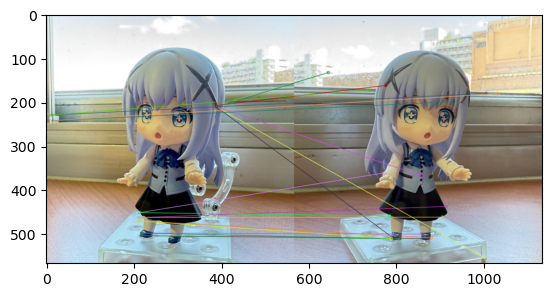

按下 Q 鍵，視窗即將關閉！


In [9]:
# 只繪製前 10 個匹配結果（避免畫面太亂）
matches_to_draw = matches[:10]
matched_img = cv2.drawMatchesKnn(
    front_face, keypoints_front,
    side_face, keypoints_side,
    matches_to_draw,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# 顯示結果
print('ORB Matching Results between Front and Side Face')
opencv_tools.show_img_by_matplotlib(matched_img)
opencv_tools.show_img_by_opencv(matched_img)

### 15-5-7 程式範例：FLANN 匹配篩選

比率測試後的匹配對數量：42
篩選後的內點匹配對數量：21
FLANN Matching Results with Homography Filtering


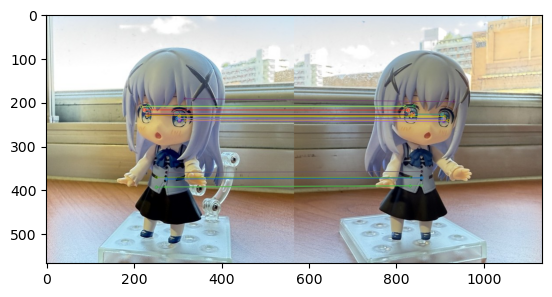

按下 Q 鍵，視窗即將關閉！


In [10]:
# 延續 15-5-4 的程式碼
# 第一道過濾：比率測試（Lowe's Ratio Test）比較「最像的第一名」與「次像的第二名」
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"比率測試後的匹配對數量：{len(good_matches)}")

# 第二道過濾：規律性篩選（RANSAC）
if len(good_matches) > 4:
    # 整理座標點格式，讓 OpenCV 能夠運算
    src_pts = np.float32([keypoints_front[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints_side[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # 計算變換規則，並標記符合規律的「內點」
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 將遮罩 mask 轉為一維串列，方便過濾
    matches_mask = mask.ravel().tolist()
    inlier_matches = [m for i, m in enumerate(good_matches) if matches_mask[i]]

    # 繪製最終精準結果
    matched_img = cv2.drawMatches(front_face, keypoints_front, side_face, keypoints_side, 
                                  inlier_matches, None, 
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    print(f"篩選後的內點匹配對數量：{len(inlier_matches)}")

    # 顯示結果
    print('FLANN Matching Results with Homography Filtering')
    opencv_tools.show_img_by_matplotlib(matched_img)
    opencv_tools.show_img_by_opencv(matched_img)

else:
    print("匹配對數量不足，無法進行規律篩選")

### 15-E-1 程式範例：透過 SIFT 匹配搜尋 icon

Feature Matching Result (SIFT + FLANN):


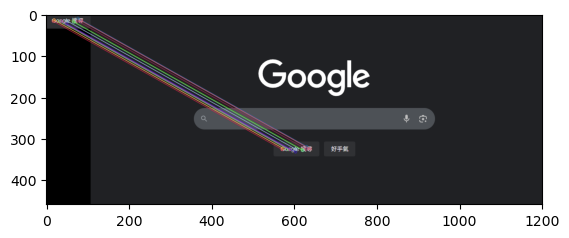

In [11]:
# 載入目標與模板影像
large_img_color = cv2.imread('sample/google_homepage.png')
template_color = cv2.imread('sample/google_search_button.png')

# 轉換為灰階
gray_large_img = cv2.cvtColor(large_img_color, cv2.COLOR_BGR2GRAY)
gray_template = cv2.cvtColor(template_color, cv2.COLOR_BGR2GRAY)

# 初始化 SIFT 與偵測特徵
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_template, None)
kp2, des2 = sift.detectAndCompute(gray_large_img, None)

# 建立 FLANN 匹配器 (針對 SIFT 使用 KD-Tree)
index_params = dict(algorithm=1, trees=5) 
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# 找出最像的前兩名 (k=2) 並進行 Ratio Test 篩選
matches = flann.knnMatch(des1, des2, k=2)
good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]

# 視覺化最佳匹配
match_result_img = cv2.drawMatches(
    template_color, kp1, large_img_color, kp2,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# 顯示結果
print("Feature Matching Result (SIFT + FLANN):")
opencv_tools.show_img_by_matplotlib(match_result_img)


Object Detection Result:


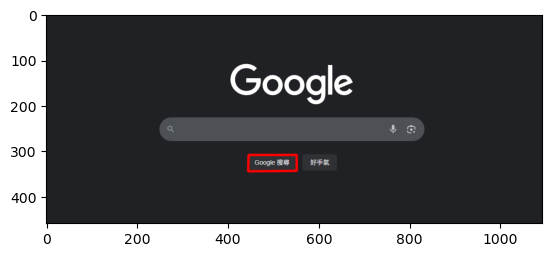

In [12]:
# 設定最少需要 4 個匹配點才能計算變換規則
MIN_MATCH_COUNT = 4

# 進行 RANSAC 匹配篩選
if len(good_matches) > MIN_MATCH_COUNT:
    # 整理匹配點座標
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # 找出 Icon 到大圖之間的變換規則 (M)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 定義 Icon 的四個邊角座標 (左上、左下、右下、右上)
    h, w = gray_template.shape
    pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)

    # 根據變換規則，計算這四個點在大圖中的新位置
    dst = cv2.perspectiveTransform(pts, M)

    # 在大圖中畫出紅框 (polylines)
    result_img = cv2.polylines(large_img_color, [np.int32(dst)], True, (0, 0, 255), 3, cv2.LINE_AA)
    
    # 顯示結果
    print("\nObject Detection Result:")
    opencv_tools.show_img_by_matplotlib(result_img)
else:
    print(f"匹配點不足，無法定位：{len(good_matches)}/{MIN_MATCH_COUNT}")